In [1]:
from pathlib import Path
import re
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from gstatsMCMC import Topography
from gstatsMCMC import MCMC
import gstatsim as gs
from sklearn.preprocessing import QuantileTransformer
import skgstat as skg
import matplotlib
import plotly.graph_objects as go

C:\Users\allyn\miniforge3\envs\gstatsMCMC\Lib\site-packages\pyproj\__init__.py:95: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()
C:\Users\allyn\miniforge3\envs\gstatsMCMC\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
matplotlib.rcParams['font.family'] = 'monospace'  # use any available family

# The usual initialization

In [19]:
df = pd.read_csv('RutfordDataGridded.csv')
folder_path = Path('LargeScaleChain')

#df = pd.read_csv('./data/BindSchadler_Macayeal_IceStreams.csv')
#folder_path = Path('data/bindshadler_macayeal/LargeScaleChain/')
rng_seed = 23198104

In [20]:
print(folder_path.exists())   # should print True
print(list(folder_path.iterdir()))  # should show the 10 seed folders

True
[WindowsPath('LargeScaleChain/125068'), WindowsPath('LargeScaleChain/157654'), WindowsPath('LargeScaleChain/165589'), WindowsPath('LargeScaleChain/209073'), WindowsPath('LargeScaleChain/271381'), WindowsPath('LargeScaleChain/315470'), WindowsPath('LargeScaleChain/654803'), WindowsPath('LargeScaleChain/821861'), WindowsPath('LargeScaleChain/842002'), WindowsPath('LargeScaleChain/973960')]


In [30]:
# create a grid of x and y coordinates
x_uniq = np.unique(df.x)
y_uniq = np.unique(df.y)

xmin = np.min(x_uniq)
xmax = np.max(x_uniq)
ymin = np.min(y_uniq)
ymax = np.max(y_uniq)

cols = len(x_uniq)
rows = len(y_uniq)

resolution = 500

xx, yy = np.meshgrid(x_uniq, y_uniq)

# load other data
dhdt = df['dhdt'].values.reshape(xx.shape)
smb = df['smb'].values.reshape(xx.shape)
velx = df['velx'].values.reshape(xx.shape)
vely = df['vely'].values.reshape(xx.shape)
bedmap_mask = df['bedmap_mask'].values.reshape(xx.shape)
bedmachine_thickness = df['bedmachine_thickness'].values.reshape(xx.shape)
bedmap_surf = df['bedmap_surf'].values.reshape(xx.shape)
highvel_mask = df['highvel_mask'].values.reshape(xx.shape)
bedmap_bed = df['bedmap_bed'].values.reshape(xx.shape)

# create conditioning data
# bed elevation measurement in grounded ice region, and bedmap topography elsewhere
cond_bed = np.where(bedmap_mask == 1, df['bed'].values.reshape(xx.shape), bedmap_bed)
df['cond_bed'] = cond_bed.flatten()

# create a mask of conditioning data
data_mask = ~np.isnan(cond_bed)

# normalize the conditioning bed data, saved to df['Nbed']
data = df['cond_bed'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal",random_state=rng_seed).fit(data)
transformed_data = nst_trans.transform(data)
df['Nbed'] = transformed_data


(-1425500.0, -1225500.0, 80000.0, 197000.0)

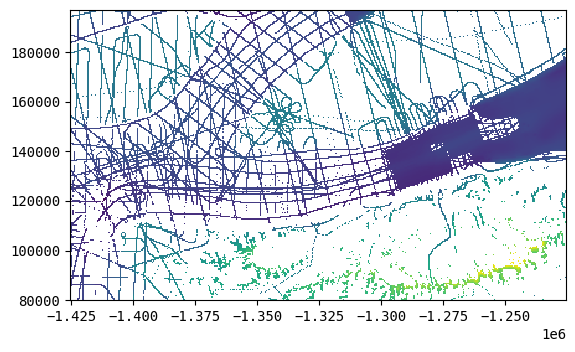

In [16]:
plt.pcolormesh(xx,yy,cond_bed)
plt.axis('scaled')

# Fetch all bed files that ends with .npy

In [18]:
import os
print(os.getcwd())

C:\Users\allyn\Glaciology\DEMOGORGN\Rutford\geostatisticalMCMC


# Compute variogram for simulated bed & cond_bed
The difference is loading simulated bed, but it's basically the same method

In [17]:
# def collect_seed_beds(folder_path: Path) -> dict[str, list[Path]]:
#     """
#     Walk each seed sub-folder and return a dict mapping
 
#     folder_path/
#         125068/
#             bed_100k.npy
#             bed_500k.npy
#             bed_1000k.npy
#         842002/
#             ...
#     """
    
#     # [seed : path to seed_folder]
#     seed_beds: dict[str, list[Path]] = {}
#     print(seed_beds)
 
#     for seed_folder in sorted(folder_path.iterdir()):
#         if not re.match(r'^[^.]', seed_folder.name):   # skip hidden dirs 
#             print('No beds added')
#             continue
#         npy_files = sorted(seed_folder.glob('*.npy'))
#         if npy_files:
#             seed_beds[seed_folder.name] = npy_files
#             print('Beds added')
 
#     return seed_beds

In [25]:
folder_path = Path("LargeScaleChain")

def collect_seed_beds(folder_path: Path) -> dict[str, list[Path]]:

    seed_beds = {}

    print("Starting function")

    for seed_folder in sorted(folder_path.iterdir()):

        print("Checking folder:", seed_folder)

        # skip non-directories and hidden folders
        if not seed_folder.is_dir() or seed_folder.name.startswith('.'):
            continue

        npy_files = sorted(seed_folder.glob("*.npy"))

        #print("Found npy files:", npy_files)

        if npy_files:
            seed_beds[seed_folder.name] = npy_files
            print("Beds added")

    return seed_beds



beds = collect_seed_beds(folder_path)

#print(beds)

Starting function
Checking folder: LargeScaleChain\125068
Beds added
Checking folder: LargeScaleChain\157654
Beds added
Checking folder: LargeScaleChain\165589
Beds added
Checking folder: LargeScaleChain\209073
Beds added
Checking folder: LargeScaleChain\271381
Beds added
Checking folder: LargeScaleChain\315470
Beds added
Checking folder: LargeScaleChain\654803
Beds added
Checking folder: LargeScaleChain\821861
Beds added
Checking folder: LargeScaleChain\842002
Beds added
Checking folder: LargeScaleChain\973960
Beds added


In [26]:
def _variogram_for_bed(df: pd.DataFrame,
                       bed_flat: np.ndarray,
                       samples: float = 0.4,
                       random_state: int = 42,
                       model: str = 'matern',
                       maxlag: int = 80_000,
                       n_lags: int = 30):
    """
    PASS IN FLATTENED BED
    
    this one passes in simulated topography to our df
    Return (bins, experimental) for one simulated bed array
    
    """
    
    
    df = df.copy()
    df['simulated_topography'] = bed_flat
 
    df_sim = df.sample(frac=samples, random_state=random_state)
    df_sim = df_sim[df_sim['simulated_topography'].notnull()]
    df_sim = df_sim[df_sim['bedmap_mask'] == 1]
 
    V = skg.Variogram(df_sim[['x', 'y']].values,
                      df_sim['simulated_topography'],
                      bin_func='even', n_lags=n_lags, maxlag=maxlag,
                      normalize=False, model=model, samples=samples)
    return V.bins, V.experimental
 
 
def _variogram_radar(df: pd.DataFrame,
                     samples: float = 0.4,
                     random_state: int = 42,
                     model: str = 'matern',
                     maxlag: int = 80_000,
                     n_lags: int = 30):
    """Return (bins, experimental) for the radar / conditioning bed."""
    df_cond = df.sample(frac=samples, random_state=random_state)
    df_cond = df_cond[df_cond['cond_bed'].notnull()]
    df_cond = df_cond[df_cond['bedmap_mask'] == 1]
 
    V = skg.Variogram(df_cond[['x', 'y']].values,
                      df_cond['cond_bed'],
                      bin_func='even', n_lags=n_lags, maxlag=maxlag,
                      normalize=False, model=model, samples=samples)
    return V.bins, V.experimental


# Put everything together, adjust your paramters & plot a pretty plot 
Tip: Run with a small sample (0.05) to see if your beds are read and fetched before running the normal routine

Beware: this runs for a while so grab a snack or doom scroll 

In [28]:
def compute_variogram_all_seeds(df: pd.DataFrame,
                                folder_path: Path,
                                samples: float = 0.4,
                                random_state: int = 42,
                                model: str = 'matern',
                                maxlag: int = 80000,
                                n_lags: int = 30,
                                figsize: tuple = (9, 5)):
    """
    For every seed folder in `folder_path`:
      - load each .npy bed
      - compute its experimental variogram
      - plot with a colour unique to that seed
 
    Also plots the single radar-measurement variogram in black
    """
 
    seed_beds   = collect_seed_beds(folder_path)
    n_seeds     = len(seed_beds)
 
    # one distinct colour per seed (tab20 has 20 hues; falls back to hsv for more)
    cmap        = plt.cm.get_cmap('tab10', n_seeds)
    seed_colors = {name: cmap(i) for i, name in enumerate(seed_beds)}
 
    # radar variogram (computed once) 
    print("Computing radar variogram …")
    xr, yr = _variogram_radar(df, samples, random_state, model, maxlag, n_lags)
 
    # figure 
    fig, ax = plt.subplots(figsize=figsize)
 
    for seed_name, npy_paths in seed_beds.items():
        color = seed_colors[seed_name]
        first = True                        # label only the first bed per seed
 
        for npy_path in npy_paths:
            print(f"  seed {seed_name} | {npy_path.name}")
            # SIMULATED BED MUST BE FLATTENED
            bed = np.load(npy_path).flatten()
            xb, yb = _variogram_for_bed(df, bed, samples, random_state,
                                         model, maxlag, n_lags)
            ax.scatter(xb, yb, s=10, color=color, alpha=0.7,
                       label=f'seed {seed_name}' if first else None)
            first = False
 
    # radar on top, always visible
    ax.scatter(xr, yr, s=20, color='black', zorder=5,
               label='radar measurements')
 
    ax.set_title('Isotropic Experimental Variogram -- all seeds')
    ax.set_xlabel('Lag (m)')
    ax.set_ylabel('Semivariance')
    ax.legend(loc='upper left', fontsize=7, markerscale=1.4,
              framealpha=0.85, ncol=max(1, n_seeds // 8 + 1))
    plt.tight_layout()
    plt.show()


# ADJUST YOUR PARAMETERS HERE

Starting function
Checking folder: LargeScaleChain\125068
Beds added
Checking folder: LargeScaleChain\157654
Beds added
Checking folder: LargeScaleChain\165589
Beds added
Checking folder: LargeScaleChain\209073
Beds added
Checking folder: LargeScaleChain\271381
Beds added
Checking folder: LargeScaleChain\315470
Beds added
Checking folder: LargeScaleChain\654803
Beds added
Checking folder: LargeScaleChain\821861
Beds added
Checking folder: LargeScaleChain\842002
Beds added
Checking folder: LargeScaleChain\973960
Beds added
Computing radar variogram …
  seed 125068 | bed_1000k.npy
  seed 125068 | bed_1910k.npy
  seed 125068 | bed_1920k.npy
  seed 125068 | bed_1930k.npy
  seed 125068 | bed_1940k.npy
  seed 125068 | bed_1950k.npy
  seed 125068 | bed_1960k.npy
  seed 125068 | bed_1970k.npy
  seed 125068 | bed_1980k.npy
  seed 125068 | bed_1990k.npy
  seed 125068 | bed_2000k.npy
  seed 125068 | bed_2910k.npy
  seed 125068 | bed_2920k.npy
  seed 125068 | bed_2930k.npy
  seed 125068 | bed_2940

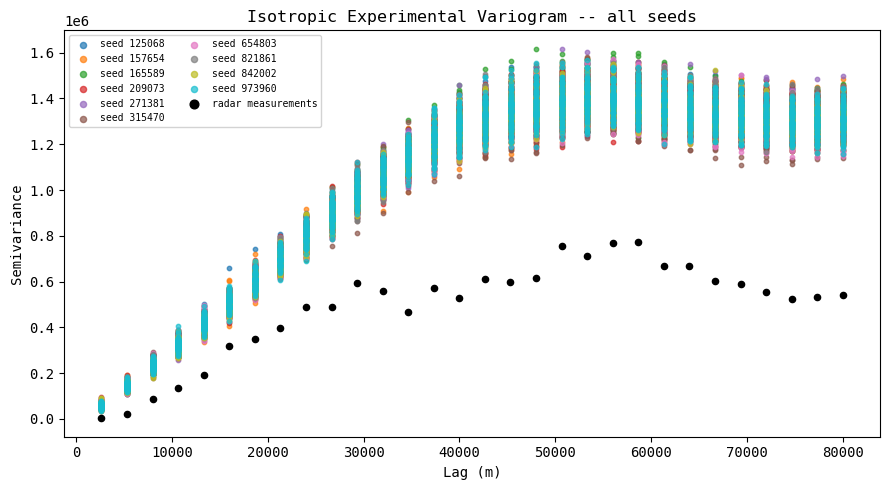

In [32]:

# add more parameters
compute_variogram_all_seeds(df = df,
                            folder_path = folder_path,
                            samples = 0.1,
                            random_state = 42,
                            model  = 'matern',
                            maxlag  = 80000,
                            n_lags = 30,
                            figsize = (9, 5))